# Real-Data Verification V2 — Fat Tails & Jumps in SPY Returns

The synthetic model zoo claims that real equity returns are **not** Gaussian: they have fat
tails and a left skew that a single geometric Brownian motion (GBM ⇒ Normal log-returns)
cannot produce, and that a **Merton jump-diffusion** captures them.  Here we test that on
**10 years of daily SPY returns**.

**Procedure.**
1. Download 10y of daily SPY, take log-returns (cached for reproducibility).
2. Measure the stylised facts: skewness, excess kurtosis, a Jarque–Bera normality test, and
   a QQ-plot against the Normal.
3. Fit Merton `(μ, σ, λ, μ_J, δ_J)` to the returns by **maximum likelihood** (the Merton
   density is a Poisson-weighted sum of Normals) and compare to a plain Normal fit by AIC.

**Success.** Significant negative skew and large excess kurtosis; Jarque–Bera rejects the
Normal; the Merton fit has a non-trivial jump component (λ>0) and a better AIC than the
Normal.  GBM is rejected as a description of real returns.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

from scipy import stats
from scipy.optimize import minimize

from config import DEFAULT_RISK_FREE_RATE as r
from data.fetcher import fetch_and_cache

COLORS = {"data": "steelblue", "normal": "crimson", "merton": "goldenrod"}
DATE = "2026-06-20"

def _flat(df):
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy(); df.columns = df.columns.get_level_values(0)
    return df

def fetch_spy():
    import yfinance as yf
    df = _flat(yf.download("SPY", period="10y", auto_adjust=True, progress=False))
    return df[["Close"]].rename(columns={"Close": "close"})

print("snapshot DATE =", DATE)

snapshot DATE = 2026-06-20


## 1. Ten years of daily SPY log-returns

In [2]:
spy = fetch_and_cache("SPY", "prices_10y", DATE, fetch_spy)
ret = np.diff(np.log(spy["close"].to_numpy(float)))
dt = 1.0 / 252.0
print(spy.index[0].date(), "->", spy.index[-1].date(), " | ", len(ret), "daily returns")
print("mean =", round(ret.mean(), 5), " std =", round(ret.std(), 5),
      " ann.vol =", round(ret.std() * np.sqrt(252) * 100, 1), "%")

2016-06-20 -> 2026-06-18  |  2513 daily returns
mean = 0.00057  std = 0.01135  ann.vol = 18.0 %


## 2. Stylised facts: skew, fat tails, normality test

A Normal has skew 0 and excess kurtosis 0.  Jarque–Bera tests that joint hypothesis.

In [3]:
sk = stats.skew(ret)
ek = stats.kurtosis(ret)          # excess kurtosis (Normal = 0)
jb = stats.jarque_bera(ret)
print("skewness          =", round(sk, 3), " (Normal 0; negative = left tail)")
print("excess kurtosis   =", round(ek, 2), " (Normal 0; positive = fat tails)")
print("Jarque-Bera stat  =", round(jb.statistic, 1), " p-value =", f"{jb.pvalue:.2e}")
print("Normal hypothesis :", "REJECTED" if jb.pvalue < 0.01 else "not rejected", "at 1%")

skewness          = -0.609  (Normal 0; negative = left tail)
excess kurtosis   = 15.22  (Normal 0; positive = fat tails)
Jarque-Bera stat  = 24412.8  p-value = 0.00e+00
Normal hypothesis : REJECTED at 1%


## 3. Fit Merton by maximum likelihood

The Merton daily log-return density conditions on the jump count `n ~ Poisson(λ·dt)`:
each branch is Normal with mean `μ·dt + n·μ_J` and variance `σ²·dt + n·δ_J²`.  We maximise
the log-likelihood over `(μ, σ, λ, μ_J, δ_J)` and compare to a Normal fit by AIC.

In [4]:
def merton_pdf(x, p, dt, n_max=12):
    mu, sig, lam, muj, dj = p
    dens = np.zeros_like(np.asarray(x, float))
    for n in range(n_max):
        w = stats.poisson.pmf(n, lam * dt)
        dens += w * stats.norm.pdf(x, loc=mu * dt + n * muj,
                                   scale=np.sqrt(sig ** 2 * dt + n * dj ** 2))
    return dens

def nll(p):
    if p[1] <= 0 or p[2] < 0 or p[4] <= 0:
        return 1e12
    return -np.sum(np.log(merton_pdf(ret, p, dt) + 1e-300))

x0 = [ret.mean() / dt, 0.8 * ret.std() / np.sqrt(dt), 20.0, -0.005, 0.02]
res = minimize(nll, x0, method="Nelder-Mead",
               options={"maxiter": 5000, "xatol": 1e-7, "fatol": 1e-7})
mu_m, sig_m, lam_m, muj_m, dj_m = res.x
print("Merton MLE:  sigma =", round(sig_m, 3), " lambda =", round(lam_m, 1),
      " mu_J =", round(muj_m, 4), " delta_J =", round(dj_m, 4))
print("  diffusion vol", round(sig_m * 100, 1), "%/yr; ", round(lam_m, 0),
      "jumps/yr of sd", round(dj_m * 100, 1), "%")

nll_normal = -np.sum(stats.norm.logpdf(ret, ret.mean(), ret.std()))
aic_merton = 2 * res.fun + 2 * 5
aic_normal = 2 * nll_normal + 2 * 2
print("AIC  Merton =", round(aic_merton, 1), " Normal =", round(aic_normal, 1),
      " -> Merton", "preferred" if aic_merton < aic_normal else "not preferred")

Merton MLE:  sigma = 0.094  lambda = 80.6  mu_J = -0.0028  delta_J = 0.0159
  diffusion vol 9.4 %/yr;  81.0 jumps/yr of sd 1.6 %
AIC  Merton = -16224.1  Normal = -15373.1  -> Merton preferred


## 4. Distribution and QQ plot

Left: the return histogram against the fitted Normal and Merton densities (log y-axis to
expose the tails).  Right: a QQ-plot against the Normal — real returns bend away from the
line in both tails (fat tails) and more so on the left (skew).

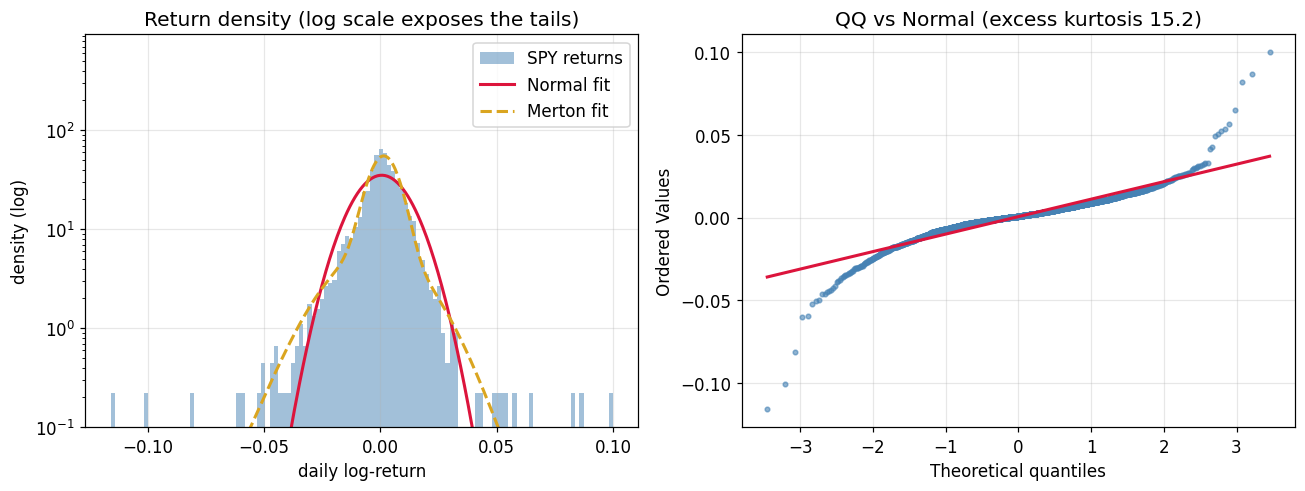

In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6))
xs = np.linspace(ret.min(), ret.max(), 400)
a1.hist(ret, bins=120, density=True, color=COLORS["data"], alpha=0.5, label="SPY returns")
a1.plot(xs, stats.norm.pdf(xs, ret.mean(), ret.std()), color=COLORS["normal"], lw=2, label="Normal fit")
a1.plot(xs, merton_pdf(xs, res.x, dt), color=COLORS["merton"], lw=2, ls="--", label="Merton fit")
a1.set_yscale("log"); a1.set_ylim(1e-1, None)
a1.set_xlabel("daily log-return"); a1.set_ylabel("density (log)")
a1.set_title("Return density (log scale exposes the tails)"); a1.legend(); a1.grid(alpha=0.3)

stats.probplot(ret, dist="norm", plot=a2)
a2.get_lines()[0].set(marker="o", markersize=3, color=COLORS["data"], alpha=0.6)
a2.get_lines()[1].set(color=COLORS["normal"], lw=2)
a2.set_title(f"QQ vs Normal (excess kurtosis {ek:.1f})"); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Verdict

In [6]:
print("V2 findings (10y daily SPY):")
print("  left skew                :", round(sk, 3), "(< 0)")
print("  excess kurtosis          :", round(ek, 2), "(>> 0, fat tails)")
print("  Jarque-Bera rejects Normal:", jb.pvalue < 0.01, f"(p={jb.pvalue:.1e})")
print("  Merton has jumps (lambda>0):", lam_m > 0)
print("  Merton beats Normal (AIC) :", aic_merton < aic_normal)
print()
print("GBM (Normal log-returns) is rejected: real SPY returns are left-skewed and")
print("fat-tailed, and a Merton jump-diffusion fits them materially better.")

V2 findings (10y daily SPY):
  left skew                : -0.609 (< 0)
  excess kurtosis          : 15.22 (>> 0, fat tails)
  Jarque-Bera rejects Normal: True (p=0.0e+00)
  Merton has jumps (lambda>0): True
  Merton beats Normal (AIC) : True

GBM (Normal log-returns) is rejected: real SPY returns are left-skewed and
fat-tailed, and a Merton jump-diffusion fits them materially better.


## Caveats (academic honesty)

- **P-measure, not Q.** This fits the *physical* return distribution.  The jump parameters
  differ from the risk-neutral smile fit in V1 (which is under Q): MLE on returns favours
  **many small jumps** (high λ, small δ_J) to match the peaked, fat-tailed daily histogram,
  whereas the smile fit favours rarer, larger down-jumps.  Both confirm a non-trivial jump
  component; the measures and the data they see are different.
- **Jump/diffusion identifiability.** At daily frequency, frequent small jumps and a higher
  diffusion σ trade off; the precise (λ, δ_J) split is not sharply identified.  The robust
  conclusions are the stylised facts and the decisive AIC improvement, not the exact λ.
- **Volatility clustering.** Merton's jumps are i.i.d.; real returns also cluster in
  volatility (GARCH/Heston territory).  Excess kurtosis here mixes jumps and clustering.